<a href="https://colab.research.google.com/github/SaraAlinejad/vae_test_1/blob/main/Alinejad_assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Chemical Applications of Machine Learning (CHEM 4930/5610) - Spring 2026

### Assignment 4 - Deadline 3/6/2026
Points 10

#### General Comments
All figures and graph should have approriate labels on the two axis, and should include a legend with appropriate labels of the different plots.

The notebook should be return in working format. That is, I should be able to reset all the output and re-run all the cells and get the same results as you obtained.

**You should start by saving a copy of the notebook to your Google Drive so you preserve all changes.**

**Please add your name as a suffix to the filname**

**Student Name**: Sara Alinejad

**AI usage statement:**
besides using AI for nice formatting and to write the math symobles easily and fast without needing latex. for writting LOO I also consulted AI agent.

### Task 1 - 10 points

In this task, we will consider data from this paper:
- Enhancing Permeability Prediction of Heterobifunctional Degraders Using Machine Learning and Metadynamics-Informed 3D Molecular Descriptors - [DOI:10.1021/acs.jcim.5c01600](https://doi.org/10.1021/acs.jcim.5c01600)

Where the authors consider the Permeability of so-called PROTAC compounds that are large and flexible molecules used in Targeted Protein Degradation.

All the dataset used in the paper, and the code use to obtain the results are given in this following Github repository:
- https://github.com/brykimjh/degrader-permeability-ml3d-metaD  

The specfic dataset that we use 32 PROTAC compounds with measured passive permeability (given in nm/s) and includes 17 2D features calculated by RDKit (see [here](https://github.com/brykimjh/degrader-permeability-ml3d-metaD/blob/main/data/calculate_2d_properties.py) for the script they are calculated), and 3 3D "ensemble" features that are obtained from molecular dynamics simulations as described in the paper.

The target value is the measured passive permeability that is experimentaly measured and given in nm/s.

The dataset can be seen here:
- https://github.com/brykimjh/degrader-permeability-ml3d-metaD/blob/main/outputs/ml_models/model_data.csv

Where the log10 transformed passive permeability is given by `P_appLog`. Note that here the passive permeability has been log transformed in based 10 using `np.log10`.

The 2D features obtained using RDKit are:
```
[
 'Molecular Weight (MW)', 'CharVol (characteristic volume)',
 'Flexibility (number of rotatable bonds / number of bonds)',
 'Number of Heavy Atoms (HA)', 'RingAtoms', 'Halogens', 'HeteroAtoms',
 'RotBonds (NRotB)', 'AllBonds', 'RingCount', 'NumStereo',
 'Fraction of sp3 Carbon Atoms (FSP3)', 'Hydrogen Bond Donors (HBD)',
 'Hydrogen Bond Acceptors (HBA)', 'cLogD^7.4',
 'Topological polar surface area (TPSA)',
 'Total non-polar surface area (TNSA)'
]
```
that includes various standard descriptors/features implemented in RDKit

and the 3D "ensemble" features obtained using MD simulations are
```
[
 'Ensemble_Average_PSA_Chloroform_ANI',
 'Ensemble_Average_Num_IMHB_Chloroform_ANI',
 'Ensemble_Average_RadiusOfGyration_Chloroform_ANI'
]
```
which inludes the average polar surface area (PSA), the average number of intramolecular hydrogen bonds (IMHB), and the average radius of gyration (that measures if the molecule is compact or extended).

#### A)
Perform regression using random forest regression model using the following hyperparameters:
- Number of tree: 100
- Maximum depth of each tree: use the default values
- Maximum number of features for each tree: use the default values

You should use the log10 transformed passive permeability values as target values.

You should perform the classification using 3 different feature set:
- 2D RDKit features
- 3D Ensemble features
- Combined set of 2D and 3D features

For each case, perform cross validation (CV) using a CV strategy of your choice, and obtain the average and standard deviation of metrics that measure the performance. You should select the metrics you wish to use.

Based on your analysis, which feature set gives the best results for the regression? Does these results fit with the results you obtained in Assignment 3?

#### D) - Optional for 2 points
For the best performing feature set from A), repeat the analysis using the measured passive permeability values in nm/s (i.e., the non log10 transformed values). Do you observe any measurable difference in using the direct values or the log10 transformed values?


In [17]:
%%bash
BASE_URL="https://raw.githubusercontent.com/brykimjh/degrader-permeability-ml3d-metaD/main"
rm -f model_data.csv mol_data.csv

wget "${BASE_URL}/outputs/ml_models/model_data.csv" &> /dev/null
wget "${BASE_URL}/data/mol_data.csv" &> /dev/null

ls -l *.csv

-rw-r--r-- 1 root root 4115 Mar  7 02:30 model_data.csv
-rw-r--r-- 1 root root 5219 Mar  7 02:30 mol_data.csv


In [2]:
!pip install rdkit mols2grid lux-api -q
import warnings
warnings.filterwarnings("ignore")
import math
import pandas as pd
import numpy as np
import lux
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import (RepeatedKFold, LeaveOneOut, cross_validate, cross_val_predict)
from sklearn.metrics import (make_scorer, mean_absolute_error, mean_squared_error, r2_score)
import warnings; warnings.filterwarnings("ignore")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.0/127.0 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.2 MB/s eta 0:00:00


In [3]:
PALETTE_LOW  = "#E05C5C"   # warm red  : low permeability
PALETTE_HIGH = "#4A90D9"   # steel blue : high permeability
PALETTE      = {"Low": PALETTE_LOW, "High": PALETTE_HIGH}

plt.rcParams.update({
    "figure.facecolor"     : "white",
    "axes.facecolor"       : "#F8F9FA",
    "axes.edgecolor"       : "#CCCCCC",
    "axes.grid"            : True,
    "grid.color"           : "white",
    "grid.linewidth"       : 1.2,
    "axes.spines.top"      : False,
    "axes.spines.right"    : False,
    "axes.labelsize"       : 12,
    "axes.titlesize"       : 13,
    "axes.titleweight"     : "bold",
    "xtick.labelsize"      : 10,
    "ytick.labelsize"      : 10,
    "legend.frameon"       : False,
    "legend.fontsize"      : 10,
    "font.family"          : "DejaVu Sans",
    "figure.dpi"           : 130,
})

In [18]:
df = pd.read_csv("model_data.csv")
print(f"Shape: {df.shape}")

Shape: (32, 21)


Button(description='Toggle Pandas/Lux', layout=Layout(top='5px', width='140px'), style=ButtonStyle())

Output()

In [5]:
features_2d = [
    'Molecular Weight (MW)', 'CharVol (characteristic volume)',
    'Flexibility (number of rotatable bonds / number of bonds)',
    'Number of Heavy Atoms (HA)', 'RingAtoms', 'Halogens', 'HeteroAtoms',
    'RotBonds (NRotB)', 'AllBonds', 'RingCount', 'NumStereo',
    'Fraction of sp3 Carbon Atoms (FSP3)', 'Hydrogen Bond Donors (HBD)',
    'Hydrogen Bond Acceptors (HBA)', 'cLogD^7.4',
    'Topological polar surface area (TPSA)',
    'Total non-polar surface area (TNSA)'
]
features_3d = [
    'Ensemble_Average_PSA_Chloroform_ANI',
    'Ensemble_Average_Num_IMHB_Chloroform_ANI',
    'Ensemble_Average_RadiusOfGyration_Chloroform_ANI'
]
features_combined = features_2d + features_3d


In [6]:
y_log = df['P_appLog'].values                # log10(P_app)


In [7]:
RF = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
CV = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

In [8]:
def rmse(y, yp):   return np.sqrt(mean_squared_error(y, yp))
def spear(y, yp):  return stats.spearmanr(y, yp).correlation

In [22]:

scorers = {
    'R2'      : make_scorer(r2_score),
    'MAE'     : make_scorer(mean_absolute_error),
    'RMSE'    : make_scorer(rmse),
    'Spearman': make_scorer(spear),
}

In [23]:
def run_cv(X, y, label):

    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    raw = cross_validate(model, X, y, cv=CV, scoring=scorers,
                         return_train_score=False)
    res = {m: {'mean': raw[f'test_{m}'].mean(),
                'std' : raw[f'test_{m}'].std(),
                'all' : raw[f'test_{m}']}
           for m in scorers}
    print(f"\n{'─'*50}\n  {label}")
    for m, lbl in zip(['R2','MAE','RMSE','Spearman'],
                      ['R²  ','MAE ','RMSE','ρ   ']):
        print(f"  {lbl}: {res[m]['mean']:+.4f} ± {res[m]['std']:.4f}")
    return res

In [11]:
X2d   = df[features_2d].values
X3d   = df[features_3d].values
Xcomb = df[features_combined].values

r_2d   = run_cv(X2d,   y_log, "2D RDKit  (17 feat) — log10 target")
r_3d   = run_cv(X3d,   y_log, "3D Ensemb ( 3 feat) — log10 target")
r_comb = run_cv(Xcomb, y_log, "2D+3D    (20 feat) — log10 target")


──────────────────────────────────────────────────
  2D RDKit  (17 feat) — log10 target
  R²  : -0.4681 ± 1.1397
  MAE : +0.4522 ± 0.1397
  RMSE: +0.5479 ± 0.1891
  ρ   : +0.3280 ± 0.4011

──────────────────────────────────────────────────
  3D Ensemb ( 3 feat) — log10 target
  R²  : -0.2106 ± 0.7548
  MAE : +0.3911 ± 0.1146
  RMSE: +0.4969 ± 0.1337
  ρ   : +0.4757 ± 0.3164

──────────────────────────────────────────────────
  2D+3D    (20 feat) — log10 target
  R²  : -0.0489 ± 0.6275
  MAE : +0.3716 ± 0.1351
  RMSE: +0.4782 ± 0.1773
  ρ   : +0.4497 ± 0.3816


In [12]:
y_raw = 10 ** y_log
# Identify best feature
best_r2 = max(r_2d['R2']['mean'], r_3d['R2']['mean'], r_comb['R2']['mean'])
Xbest, best_name = {
    r_2d['R2']['mean']  : (X2d,   "2D"),
    r_3d['R2']['mean']  : (X3d,   "3D"),
    r_comb['R2']['mean']: (Xcomb, "2D+3D"),
}[best_r2]

r_raw = run_cv(Xbest, y_raw, f"{best_name} — raw P_app [nm/s]")


──────────────────────────────────────────────────
  2D+3D — raw P_app [nm/s]
  R²  : -0.5267 ± 1.3565
  MAE : +7.6759 ± 2.0658
  RMSE: +9.9549 ± 2.8786
  ρ   : +0.4067 ± 0.3659


In [13]:
print("\n\n" + "═"*85)
print(f"  {'Feature Set':<22} {'R²':>10} {'MAE':>10} {'RMSE':>15} {'Spearman':>15}")
print("═"*85)
for name, r in [("2D (log10)", r_2d), ("3D (log10)", r_3d),
                ("2D+3D (log10)", r_comb), (f"{best_name} (raw)", r_raw)]:
    print(f"  {name:<22} "
          f"{r['R2']['mean']:+.3f}±{r['R2']['std']:.3f}  "
          f"{r['MAE']['mean']:.4f}±{r['MAE']['std']:.4f}  "
          f"{r['RMSE']['mean']:.4f}±{r['RMSE']['std']:.4f}  "
          f"{r['Spearman']['mean']:+.3f}±{r['Spearman']['std']:.3f}")



═════════════════════════════════════════════════════════════════════════════════════
  Feature Set                    R²        MAE            RMSE        Spearman
═════════════════════════════════════════════════════════════════════════════════════
  2D (log10)             -0.468±1.140  0.4522±0.1397  0.5479±0.1891  +0.328±0.401
  3D (log10)             -0.211±0.755  0.3911±0.1146  0.4969±0.1337  +0.476±0.316
  2D+3D (log10)          -0.049±0.627  0.3716±0.1351  0.4782±0.1773  +0.450±0.382
  2D+3D (raw)            -0.527±1.356  7.6759±2.0658  9.9549±2.8786  +0.407±0.366


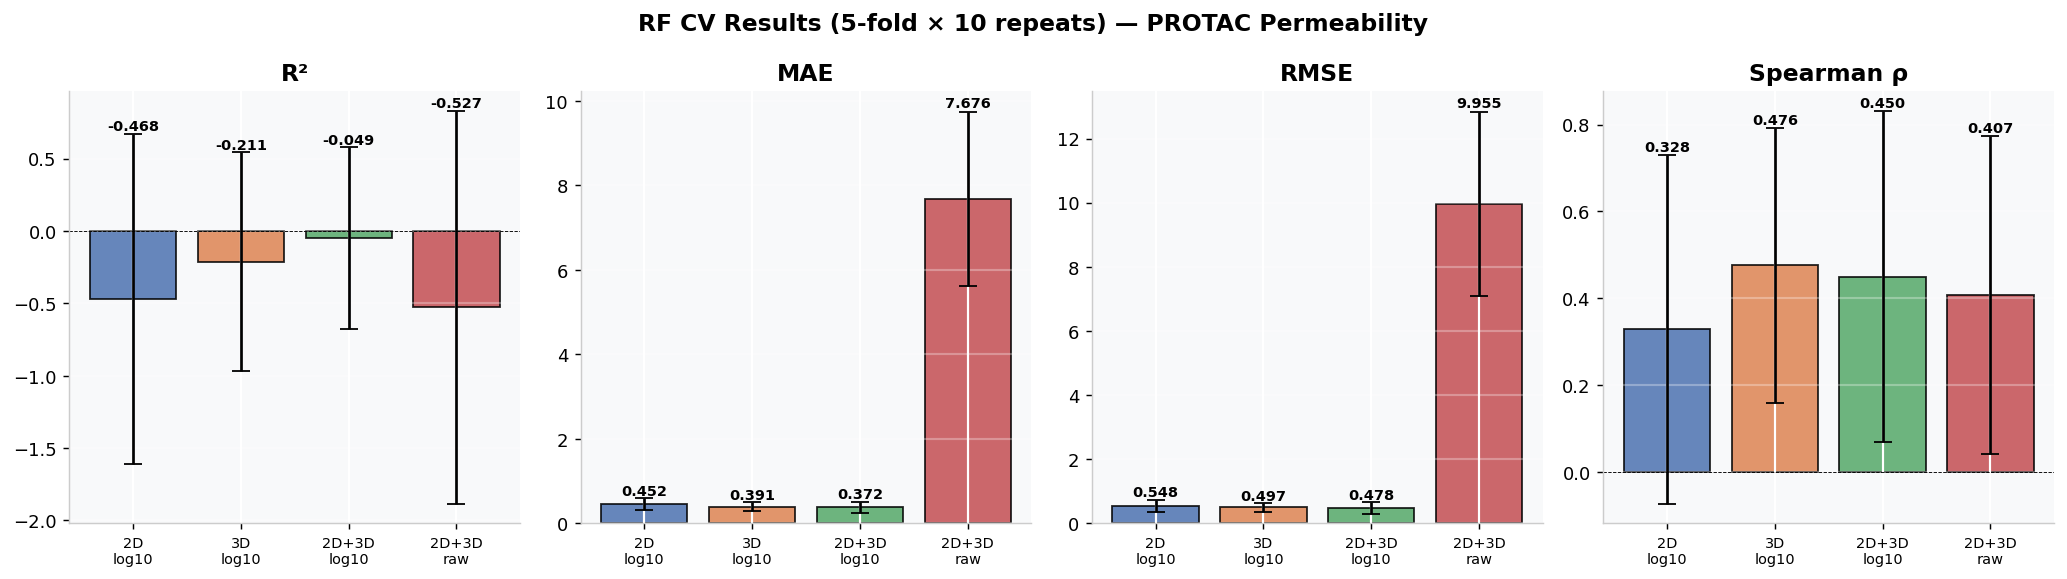

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
fig.suptitle("RF CV Results (5-fold × 10 repeats) — PROTAC Permeability",
             fontsize=13, fontweight='bold')

labels = ['2D\nlog10', '3D\nlog10', '2D+3D\nlog10', f'{best_name}\nraw']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
results = [r_2d, r_3d, r_comb, r_raw]

for ax, metric, ylabel in zip(axes,
        ['R2', 'MAE', 'RMSE', 'Spearman'],
        ['R²', 'MAE', 'RMSE', 'Spearman ρ']):
    means = [r[metric]['mean'] for r in results]
    stds  = [r[metric]['std']  for r in results]
    bars  = ax.bar(labels, means, yerr=stds, color=colors,
                   capsize=5, alpha=0.85, edgecolor='k')
    for b, m, s in zip(bars, means, stds):
        ax.text(b.get_x()+b.get_width()/2,
                b.get_height()+s+0.005*max(abs(m), 0.01),
                f'{m:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(ylabel, fontweight='bold')
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

negative R² maybe comes from computing R² on only 6 test points at a time since with that few points, one bad prediction tanks the whole metric. in the hope to solve this, I used LOO (next code) that maximises the training data per fold (31 out of 32) and gives one honest out-of-sample prediction per compound

catastrophic MAE (7.68) and RMSE (9.95) with giant error bars!
This is exactly expected and actually validates the log-transform.  A few high-permeability outliers completely dominate MSE/MAE in nm/s space, producing enormous and unreliable estimates. This is precisely why log10 is the correct target space. Spearman can be considered as primary metric beacuse of being invariant under log10 as expected (Rank-based).

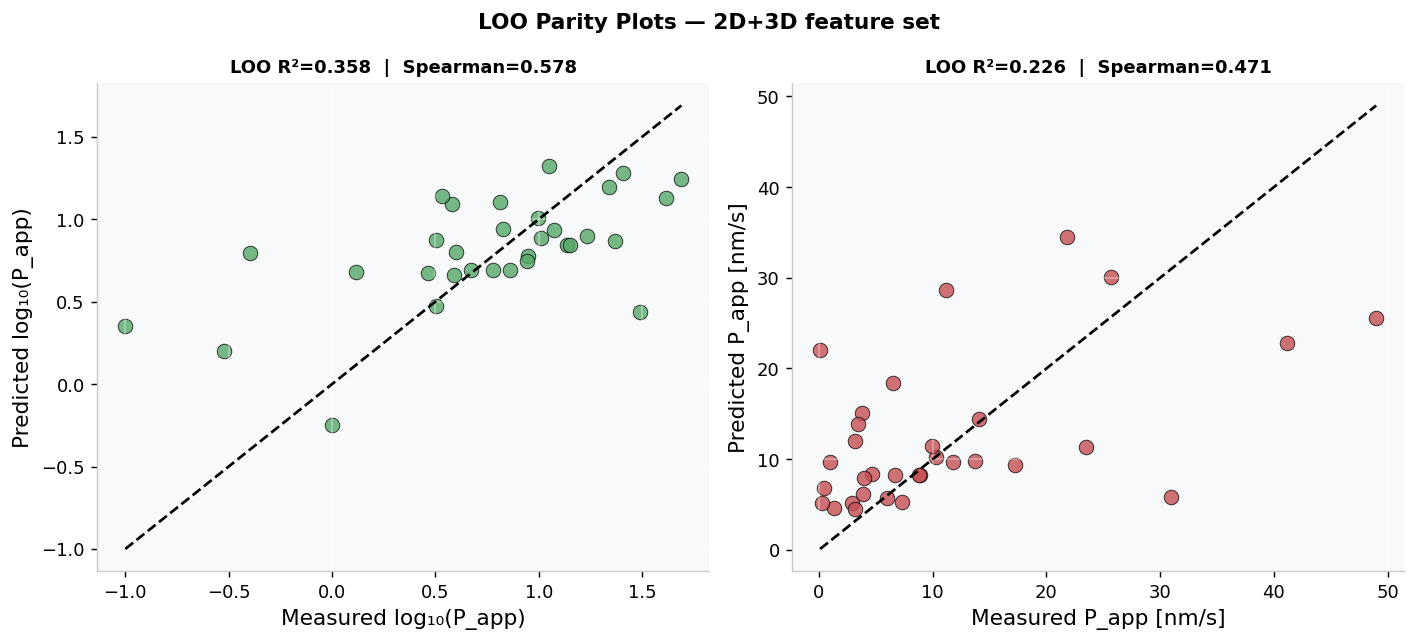

In [15]:
# Parity plot  — log10 vs raw for best feature set
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 5))
fig2.suptitle(f"LOO Parity Plots — {best_name} feature set", fontsize=12, fontweight='bold')

for ax, y_arr, ylabel, color in zip(
        axes2,
        [y_log, y_raw],
        [f'log₁₀(P_app)', f'P_app [nm/s]'],
        ['#55A868', '#C44E52']):
    m = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    yp = cross_val_predict(m, Xbest, y_arr, cv=LeaveOneOut())   #
    r2_loo = r2_score(y_arr, yp)
    sp_loo = stats.spearmanr(y_arr, yp).correlation
    ax.scatter(y_arr, yp, c=color, s=65, alpha=0.8, edgecolors='k', lw=0.5)
    lo, hi = min(y_arr.min(), yp.min()), max(y_arr.max(), yp.max())
    ax.plot([lo,hi],[lo,hi],'k--',lw=1.5)
    ax.set_xlabel(f"Measured {ylabel}"); ax.set_ylabel(f"Predicted {ylabel}")
    ax.set_title(f"LOO R²={r2_loo:.3f}  |  Spearman={sp_loo:.3f}", fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


R² will look much worse for raw nm/s, because a few high-permeability outliers dominate the sum-of-squares in nm/s space, inflating errors.